In [ ]:

import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec
from utils import standardization
from utils import metrics
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()


print('FINITO')

FINITO


In [3]:

X_train, X_test= standardization(X_train, X_test)

# Creare il modello SVM
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

# Calcolo e stampa delle metriche
metrics(y_test, y_pred)

Accuratezza: 0.77
Precision: 0.77
Recall: 0.77
F1-score: 0.77
F2-score: 0.77


In [5]:
param_grid = {
    'C': [1, 10],
    'gamma': ['scale'] + [0.1,1],
    'kernel': ['rbf','poly']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("I Migliori parametri trovati sono:", grid_search.best_params_)
best_model = grid_search.best_estimator_

KeyboardInterrupt: 

In [7]:

# Creare il modello SVM
model = SVC(C=10, gamma='scale', kernel='rbf')
model.fit(X_train, y_train)

# Prevedere le etichette per il set di test
y_pred = model.predict(X_test)

# Calcolo e stampa delle metriche
metrics(y_test, y_pred)

Accuratezza: 0.93
Precision: 0.93
Recall: 0.93
F1-score: 0.93
F2-score: 0.93


Accuratezza per ogni fold: [0.8718718718718719, 0.8858858858858859, 0.8758758758758759, 0.8788788788788788, 0.8858858858858859, 0.8898898898898899, 0.8828828828828829, 0.9049049049049049, 0.8768768768768769, 0.8748748748748749]
Accuratezza media dopo K-Fold: 0.8828
Precisione media dopo K-Fold: 0.8830
Recall media dopo K-Fold: 0.8827
F1-score medio dopo K-Fold: 0.8820
F2-score medio dopo K-Fold: 0.8822


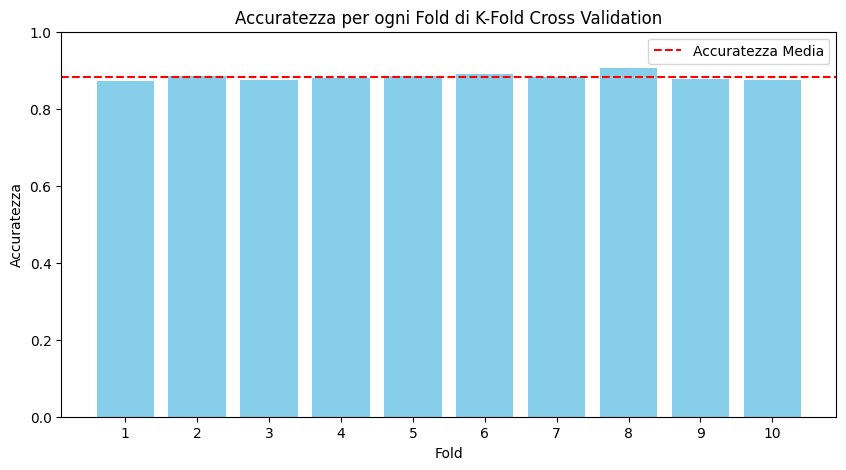

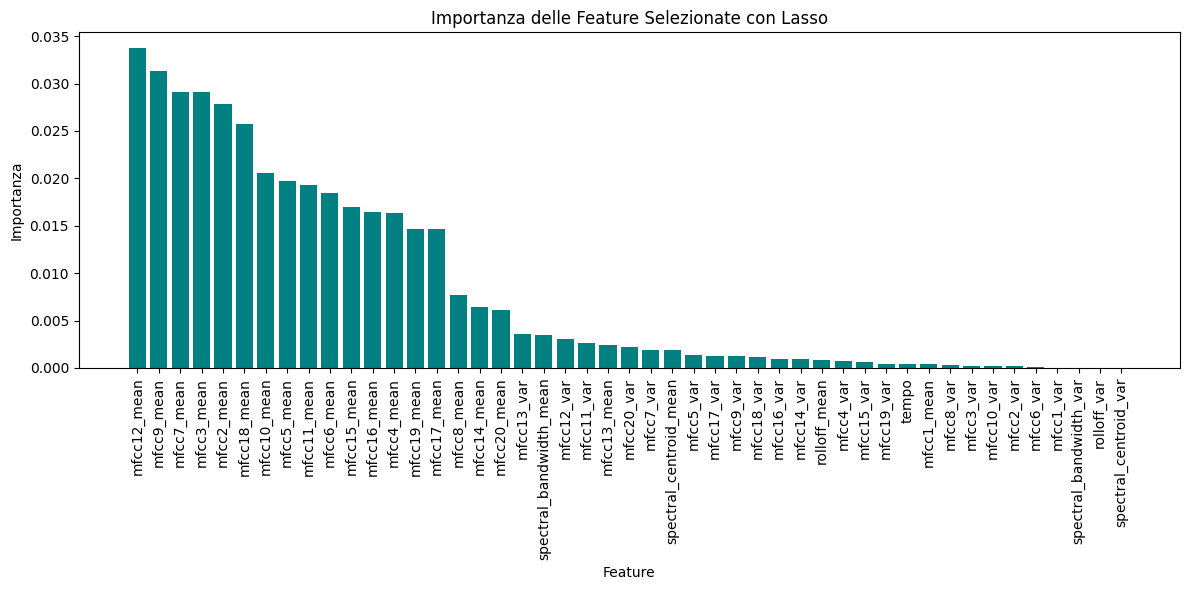

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Carica i dati dal CSV
file_path = 'Data/features_3_sec.csv'
data = pd.read_csv(file_path)

# Separare le caratteristiche e le etichette
X = data.drop(columns=['filename', 'label'])
y = data['label']

# Converti le etichette in valori numerici
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Inizializza la cross-validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Variabili per la valutazione
accuracies = []
precisions = []
recalls = []
f1_scores = []
f2_scores = []
importances_dict = {}

# Loop attraverso ogni fold
for train_index, test_index in kf.split(X, y_encoded):
    X_train, X_test = X.values[train_index], X.values[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Selezione delle feature con Lasso
    lasso = Lasso(alpha=0.1, max_iter=10000)
    lasso.fit(X_train, y_train)

    # Seleziona le feature non nulle
    selected_features = np.where(lasso.coef_ != 0)[0]
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]

    # Standardizza le caratteristiche selezionate
    scaler = StandardScaler()
    X_train_selected = scaler.fit_transform(X_train_selected)
    X_test_selected = scaler.transform(X_test_selected)

    # Creare il modello SVM
    model = SVC(C=10, gamma='scale', kernel='rbf')
    model.fit(X_train_selected, y_train)

    # Prevedere le etichette per il set di test
    y_pred = model.predict(X_test_selected)

    # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')

    # Aggiungere le metriche alla lista
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    f2_scores.append(f2)

    # Salvare le importanze con il nome della feature
    for i, feature_index in enumerate(selected_features):
        feature_name = X.columns[feature_index]
        if feature_name in importances_dict:
            importances_dict[feature_name].append(abs(lasso.coef_[feature_index]))
        else:
            importances_dict[feature_name] = [abs(lasso.coef_[feature_index])]

# Risultati finali
print(f"Accuratezza per ogni fold: {accuracies}")
print(f"Accuratezza media dopo K-Fold: {np.mean(accuracies):.4f}")
print(f"Precisione media dopo K-Fold: {np.mean(precisions):.4f}")
print(f"Recall media dopo K-Fold: {np.mean(recalls):.4f}")
print(f"F1-score medio dopo K-Fold: {np.mean(f1_scores):.4f}")
print(f"F2-score medio dopo K-Fold: {np.mean(f2_scores):.4f}")
selected_feature_names = X.columns[selected_features].tolist()
print("\nFeature selezionate dal Lasso:", selected_feature_names)
print("Indice di feature selezionate:",(selected_features))
print("Numero di feature selezionate:", len(selected_feature_names))

# Calcolare la media delle importanze delle feature selezionate
mean_importances = {feature: np.mean(importance_list) for feature, importance_list in importances_dict.items()}

# Ordina le feature in base alla loro importanza media
sorted_features = sorted(mean_importances, key=mean_importances.get, reverse=True)
sorted_importances = [mean_importances[feature] for feature in sorted_features]

# Grafico delle accuratezze per fold
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(accuracies) + 1), accuracies, color='skyblue')
plt.xlabel('Fold')
plt.ylabel('Accuratezza')
plt.title('Accuratezza per ogni Fold di K-Fold Cross Validation')
plt.ylim(0, 1)
plt.xticks(range(1, len(accuracies) + 1))
plt.axhline(y=np.mean(accuracies), color='r', linestyle='--', label='Accuratezza Media')
plt.legend()
plt.show()

# Grafico dell'importanza delle feature (con assi scambiati)
plt.figure(figsize=(12, 6))
plt.bar(sorted_features, sorted_importances, color='teal')
plt.ylabel('Importanza')
plt.xlabel('Feature')
plt.title('Importanza delle Feature Selezionate con Lasso')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
